### Step 1: Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

### Step 2: Load and Explore the Dataset

In [ ]:
data = pd.read_csv('Telco-Customer-Churn.csv')
print(data.head())
print(data.info())
print(data.isnull().sum())     

   customerID  gender  SeniorCitizen  ... MonthlyCharges TotalCharges  Churn
0  7590-VHVEG  Female              0  ...          29.85        29.85     No
1  5575-GNVDE    Male              0  ...          56.95       1889.5     No
2  3668-QPYBK    Male              0  ...          53.85       108.15    Yes
3  7795-CFOCW    Male              0  ...          42.30      1840.75     No
4  9237-HQITU  Female              0  ...          70.70       151.65    Yes

[5 rows x 21 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-

In [26]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [27]:
data['TotalCharges'].isnull().sum()

11

In [28]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


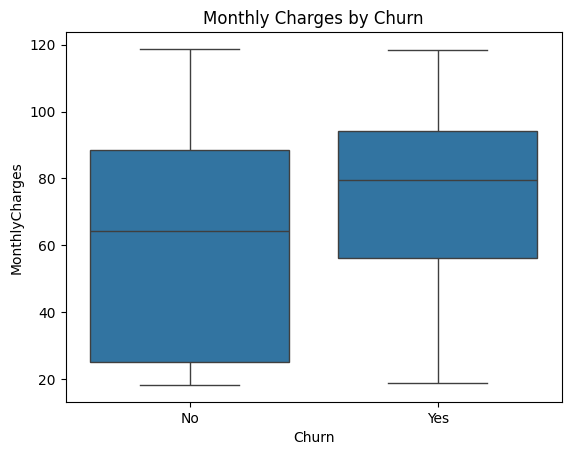

In [29]:
# Optional: Visualize relationships (e.g., MonthlyCharges vs. Churn)
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title("Monthly Charges by Churn")
plt.show()

### Step 3: Preprocess the Data

In [30]:
data = data.drop(['customerID'], axis=1)

# Use one-hot encoding for categorical variables
data = pd.get_dummies(data, drop_first=True)
data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True


In [31]:
# Separate features and target variable
X = data.drop('Churn_Yes', axis=1)
y = data['Churn_Yes']

# Standardize the numerical features
scaler = StandardScaler()
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[numerical_features] = scaler.fit_transform(X[numerical_features])

### Step 4: Split the Data

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Step 5: Train the SVM Model

In [33]:
# Initialize the SVM classifier with an RBF kernel
svc_model = SVC(kernel='rbf', C=1, probability=True)

# Train the model
svc_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Step 6: Evaluate the Model

In [34]:
y_pred = svc_model.predict(X_test)

# Classification report and confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[940  95]
 [194 180]]

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1035
        True       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### Classification Report Analysis
The model achieves an overall accuracy of 79% and a churn precision of 65%, indicating that customers identified as potential churners are often correctly classified. However, the churn recall is only 48%, meaning the model fails to identify more than half of the customers who actually churn. Since the primary objective of churn prediction is typically to identify at-risk customers before they leave, improving recall should be a priority, even if it results in a modest decrease in precision.

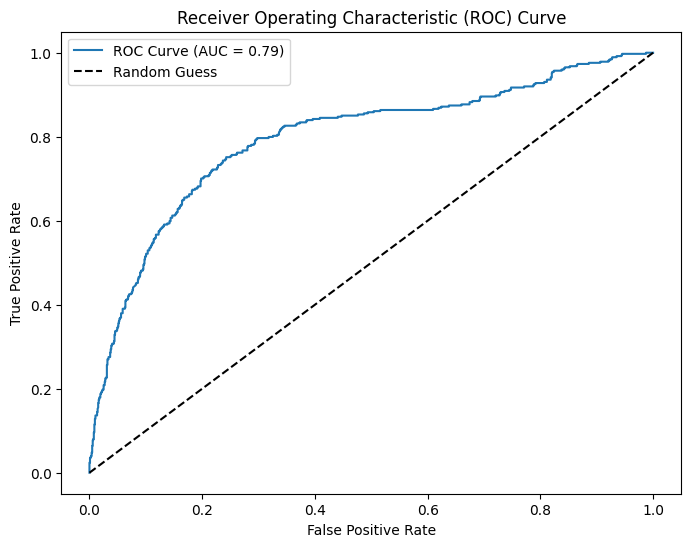

In [35]:
# ROC Curve and AUC
y_prob = svc_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)


fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

### Step 7: Optimize the Model

Best Parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

Optimized Model Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1035
        True       0.67      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



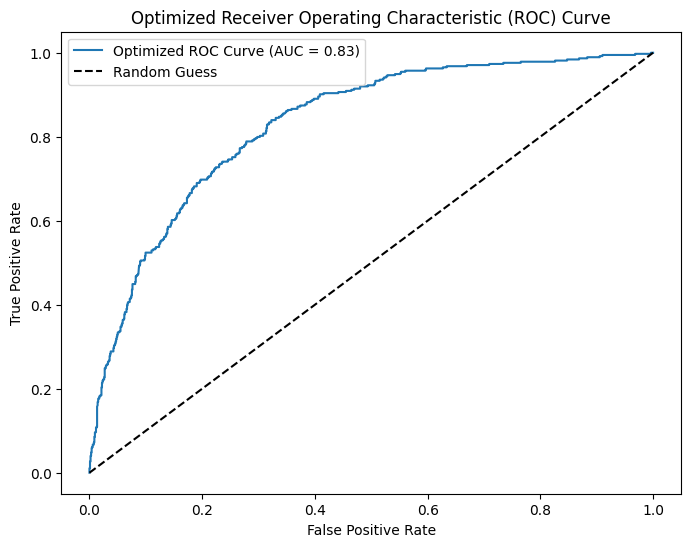

In [36]:
# Step 7: Optimize the Model
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}


grid_search = GridSearchCV(SVC(probability=True), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)


# Print the best parameters
print("Best Parameters:", grid_search.best_params_)


# Train the optimized model
optimized_model = grid_search.best_estimator_
optimized_model.fit(X_train, y_train)


# Evaluate the optimized model
y_pred_optimized = optimized_model.predict(X_test)
print("\nOptimized Model Classification Report:")
print(classification_report(y_test, y_pred_optimized))


# Recalculate ROC Curve for the optimized model
y_prob_optimized = optimized_model.predict_proba(X_test)[:, 1]
roc_auc_optimized = roc_auc_score(y_test, y_prob_optimized)


fpr_optimized, tpr_optimized, thresholds_optimized = roc_curve(y_test, y_prob_optimized)
plt.figure(figsize=(8, 6))
plt.plot(fpr_optimized, tpr_optimized, label=f'Optimized ROC Curve (AUC = {roc_auc_optimized:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Optimized Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [37]:
y_pred_optimized = optimized_model.predict(X_test)

print("Confusion Matrix for Optimized Model:")
print(confusion_matrix(y_test, y_pred_optimized))

Confusion Matrix for Optimized Model:
[[944  91]
 [192 182]]
